# Comprehensive Evaluation Results Analysis Notebook

**⚠️ IMPORTANT: This notebook ONLY analyzes locally stored results.**
- ✅ Reads CSV files from disk across multiple result directories
- ✅ Generates comprehensive visualizations and statistics
- ✅ Compares strategies across k values, overlap sizes, and chunk configurations
- ❌ Does NOT query Pinecone
- ❌ Does NOT query Gemini or any APIs
- ❌ Does NOT require API keys

**Workflow:**
1. **Generate Results** (with API access): Run `generate_evaluation_results.py`
   - This queries Pinecone/Gemini and saves CSV files locally
   - Requires API keys and internet connection
   
2. **Analyze Results** (no API access needed): Run this notebook
   - Loads pre-generated CSV files from multiple directories
   - Generates comprehensive visualizations and comparisons
   - Can run offline after results are generated

**Strategies evaluated:**
- **baseline**: Simple character-based chunking
- **sentence**: Sentence-aware chunking  
- **adaptive**: Dynamic strategy selection based on document type

**Comparisons performed:**
- For each strategy: Compare performance across k values (k3, k5, k10)
- For each strategy: Compare performance across overlap sizes
- For each strategy: Compare performance across chunk sizes (small, medium)

**Usage:**
1. First, run `generate_evaluation_results.py` to generate CSV results
2. Then run this notebook to visualize and analyze the results across all configurations

All plots will be displayed inline for easy viewing and analysis.

## 1. Setup and Configuration

In [6]:
import sys
from pathlib import Path
from collections import defaultdict

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent))

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for inline plots
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Configuration - Load results from all available directories
BASE_DIR = Path(".")
RESULTS_DIRS = {
    "k3": BASE_DIR / "results_k3",
    "k5": BASE_DIR / "results_k5", 
    "k10": BASE_DIR / "results_k10",
    "small_chunks": BASE_DIR / "chunk_config_evaluations" / "small_chunks" / "evaluation_results",
    "medium_chunks": BASE_DIR / "chunk_config_evaluations" / "medium_chunks" / "evaluation_results",
    "small_overlap": BASE_DIR / "chunk_config_evaluations" / "small_overlap" / "evaluation_results",
}

ENABLE_ANSWER_ANALYSIS = False  # Set to True if you have answer data in results

print("✅ Imports loaded successfully!")
print(f"📁 Working directory: {Path.cwd()}")
print(f"📊 Looking for results in: {", ".join(RESULTS_DIRS.keys())}")


✅ Imports loaded successfully!
📁 Working directory: c:\Users\LENOVO\OneDrive - Technion\Desktop\DataSience\semester8\lab2\evaluation
📊 Looking for results in: k3, k5, k10, small_chunks, medium_chunks, small_overlap


# Load all available evaluation results
all_results = {}
all_strategy_stats = {}
all_namespace_stats = {}

print("📂 Loading evaluation results from all directories...\n")

for config_name, config_dir in RESULTS_DIRS.items():
    csv_path = config_dir / "evaluation_results.csv"
    stats_path = config_dir / "strategy_statistics.csv"
    namespace_path = config_dir / "namespace_statistics.csv"
    
    if csv_path.exists():
        df_config = pd.read_csv(csv_path, encoding="utf-8")
        df_config['config'] = config_name  # Add configuration identifier
        all_results[config_name] = df_config
        print(f"✅ Loaded {len(df_config)} results from {config_name}")
        
        if stats_path.exists():
            stats = pd.read_csv(stats_path, encoding="utf-8")
            stats['config'] = config_name
            all_strategy_stats[config_name] = stats
            
        if namespace_path.exists():
            ns_stats = pd.read_csv(namespace_path, encoding="utf-8")
            ns_stats['config'] = config_name
            all_namespace_stats[config_name] = ns_stats
    else:
        print(f"⚠️  Results not found in {config_name}: {csv_path}")

# Combine all results
if all_results:
    df = pd.concat(all_results.values(), ignore_index=True)
    print(f"\n✅ Combined {len(df)} evaluation results from {len(all_results)} configurations")
    print(f"📊 Strategies: {", ".join(df["strategy"].unique())}")
    print(f"📝 Queries: {df["query"].nunique()}")
    print(f"📋 Configurations: {", ".join(df["config"].unique())}")
    print(f"\n📋 Sample data:")
    print(df.head())
    
    # Combine strategy stats if available
    strategy_stats = None
    if all_strategy_stats:
        strategy_stats = pd.concat(all_strategy_stats.values(), ignore_index=True)
        print(f"\n✅ Loaded strategy statistics from {len(all_strategy_stats)} configurations")
    
    # Combine namespace stats if available
    namespace_stats = None
    if all_namespace_stats:
        namespace_stats = pd.concat(all_namespace_stats.values(), ignore_index=True)
        print(f"✅ Loaded namespace statistics from {len(all_namespace_stats)} configurations")
else:
    print("\n❌ No evaluation results found! Please run generate_evaluation_results.py first.")
    raise FileNotFoundError("No evaluation results found")


In [7]:
# Load all available evaluation results
all_results = {}
all_strategy_stats = {}
all_namespace_stats = {}

print("📂 Loading evaluation results from all directories...\n")

for config_name, config_dir in RESULTS_DIRS.items():
    csv_path = config_dir / "evaluation_results.csv"
    stats_path = config_dir / "strategy_statistics.csv"
    namespace_path = config_dir / "namespace_statistics.csv"
    
    if csv_path.exists():
        df_config = pd.read_csv(csv_path, encoding="utf-8")
        df_config['config'] = config_name  # Add configuration identifier
        all_results[config_name] = df_config
        print(f"✅ Loaded {len(df_config)} results from {config_name}")
        
        if stats_path.exists():
            stats = pd.read_csv(stats_path, encoding="utf-8")
            stats['config'] = config_name
            all_strategy_stats[config_name] = stats
            
        if namespace_path.exists():
            ns_stats = pd.read_csv(namespace_path, encoding="utf-8")
            ns_stats['config'] = config_name
            all_namespace_stats[config_name] = ns_stats
    else:
        print(f"⚠️  Results not found in {config_name}: {csv_path}")

# Combine all results
if all_results:
    df = pd.concat(all_results.values(), ignore_index=True)
    print(f"\n✅ Combined {len(df)} evaluation results from {len(all_results)} configurations")
    print(f"📊 Strategies: {", ".join(df["strategy"].unique())}")
    print(f"📝 Queries: {df["query"].nunique()}")
    print(f"📋 Configurations: {", ".join(df["config"].unique())}")
    print(f"\n📋 Sample data:")
    print(df.head())
    
    # Combine strategy stats if available
    strategy_stats = None
    if all_strategy_stats:
        strategy_stats = pd.concat(all_strategy_stats.values(), ignore_index=True)
        print(f"\n✅ Loaded strategy statistics from {len(all_strategy_stats)} configurations")
    
    # Combine namespace stats if available
    namespace_stats = None
    if all_namespace_stats:
        namespace_stats = pd.concat(all_namespace_stats.values(), ignore_index=True)
        print(f"✅ Loaded namespace statistics from {len(all_namespace_stats)} configurations")
else:
    print("\n❌ No evaluation results found! Please run generate_evaluation_results.py first.")
    raise FileNotFoundError("No evaluation results found")


📂 Loading evaluation results from all directories...

✅ Loaded 20 results from k3
✅ Loaded 20 results from k5
✅ Loaded 20 results from k10
✅ Loaded 60 results from small_chunks
✅ Loaded 60 results from medium_chunks
✅ Loaded 60 results from small_overlap

✅ Combined 240 evaluation results from 6 configurations
📊 Strategies: adaptive, baseline, sentence
📝 Queries: 20
📋 Configurations: k3, k5, k10, small_chunks, medium_chunks, small_overlap

📋 Sample data:
                                               query category  strategy  \
0                                 איך משלמים ארנונה?  general  adaptive   
1                  מה שעות הפעילות של המוקד העירוני?  general  adaptive   
2   מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?  general  adaptive   
3  האם ניתן ליצור קשר עם המוקד העירוני בנושאים שו...  general  adaptive   
4               אם אני רוצה לשלם ארנונה — למי פונים?  general  adaptive   

  expected_namespace detected_namespace  namespace_correct  avg_score  \
0             arn

## 3. Compute Statistics (if not already computed)

In [8]:
# Compute statistics if not already loaded
if strategy_stats is None:
    print("📊 Computing strategy statistics...")
    strategy_stats = df.groupby("strategy").agg({
        "avg_score": ["mean", "std", "min", "max"],
        "max_score": ["mean", "std"],
        "namespace_correct": "mean",
        "num_results": "mean",
        "unique_docs": "mean",
    }).round(4)
    strategy_stats.columns = ["_".join(col).strip() for col in strategy_stats.columns]
    strategy_stats = strategy_stats.reset_index()
    print("✅ Strategy statistics computed")

if namespace_stats is None:
    print("📊 Computing namespace statistics...")
    # Filter out rows with empty expected_namespace values
    df_with_namespace = df[df["expected_namespace"].notna() & (df["expected_namespace"].str.strip() != "")]
    if len(df_with_namespace) > 0:
        namespace_stats = df_with_namespace.groupby(["expected_namespace", "strategy"]).agg({
            "namespace_correct": ["mean", "count"],
        }).round(4)
        namespace_stats.columns = ["accuracy", "count"]
        namespace_stats = namespace_stats.reset_index()
        print("✅ Namespace statistics computed")
    else:
        namespace_stats = pd.DataFrame(columns=["expected_namespace", "strategy", "accuracy", "count"])
        print("⚠️ No namespace data available (expected_namespace column is empty)")

# Display statistics
print("\n📈 Strategy Statistics:")
print(strategy_stats.to_string(index=False))
print("\n📈 Namespace Statistics:")
print(namespace_stats.head(10))


📈 Strategy Statistics:
strategy  avg_score_mean  avg_score_std  avg_score_min  avg_score_max  max_score_mean  max_score_std  namespace_correct_mean  num_results_mean  unique_docs_mean  precision_mean  precision_std  recall_mean  recall_std  accuracy_mean  accuracy_std        config
adaptive          0.5259         0.1247         0.2677         0.6881          0.5443         0.1179                     1.0               3.0              2.40            0.10         0.2190       0.1000      0.2190           0.10        0.2190            k3
adaptive          0.5166         0.1284         0.2517         0.6812          0.5443         0.1179                     1.0               5.0              3.50            0.08         0.1765       0.1333      0.2942           0.08        0.1765            k5
adaptive          0.5030         0.1347         0.2281         0.6748          0.5443         0.1179                     1.0              10.0              6.20            0.06         0.1188     

## 4. Visualizations - Strategy Comparison

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt


RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


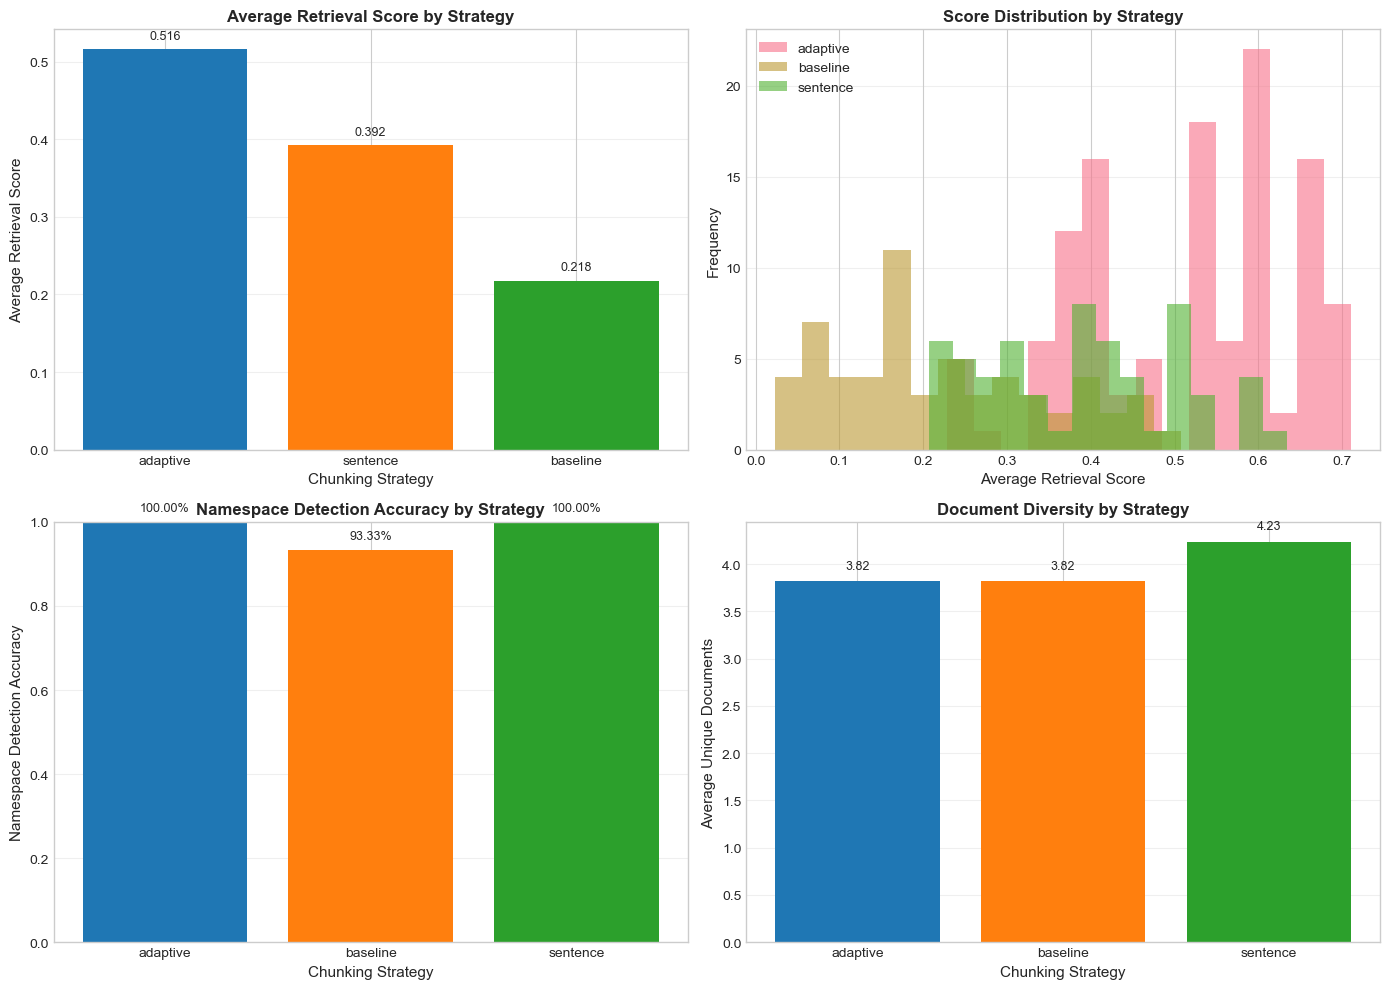

✅ Saved plot to results\strategy_comparison.png


In [10]:
# Strategy comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average score comparison
ax = axes[0, 0]
strategy_means = df.groupby("strategy")["avg_score"].mean().sort_values(ascending=False)
bars = ax.bar(strategy_means.index, strategy_means.values, 
              color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set_ylabel("Average Retrieval Score", fontsize=11)
ax.set_xlabel("Chunking Strategy", fontsize=11)
ax.set_title("Average Retrieval Score by Strategy", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
for i, (strategy, val) in enumerate(strategy_means.items()):
    ax.text(i, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Score distribution
ax = axes[0, 1]
for strategy in df["strategy"].unique():
    scores = df[df["strategy"] == strategy]["avg_score"]
    ax.hist(scores, alpha=0.6, label=strategy, bins=15)
ax.set_xlabel("Average Retrieval Score", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title("Score Distribution by Strategy", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Namespace accuracy
ax = axes[1, 0]
namespace_acc = df.groupby("strategy")["namespace_correct"].mean()
bars = ax.bar(namespace_acc.index, namespace_acc.values,
              color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set_ylabel("Namespace Detection Accuracy", fontsize=11)
ax.set_xlabel("Chunking Strategy", fontsize=11)
ax.set_title("Namespace Detection Accuracy by Strategy", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
for i, (strategy, val) in enumerate(namespace_acc.items()):
    ax.text(i, val + 0.02, f"{val:.2%}", ha="center", va="bottom", fontsize=9)

# Unique documents
ax = axes[1, 1]
unique_docs_means = df.groupby("strategy")["unique_docs"].mean()
bars = ax.bar(unique_docs_means.index, unique_docs_means.values,
              color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set_ylabel("Average Unique Documents", fontsize=11)
ax.set_xlabel("Chunking Strategy", fontsize=11)
ax.set_title("Document Diversity by Strategy", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
for i, (strategy, val) in enumerate(unique_docs_means.items()):
    ax.text(i, val + 0.1, f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "strategy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Saved plot to {RESULTS_DIR / 'strategy_comparison.png'}")

## 5. Visualization - Namespace Accuracy Heatmap

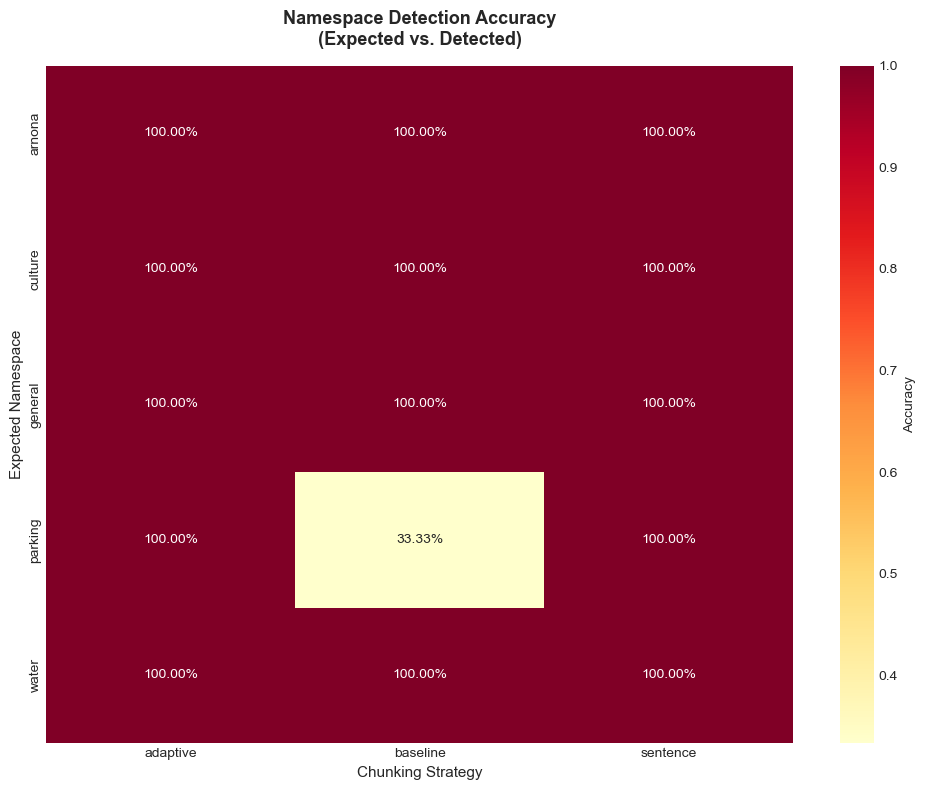

✅ Saved plot to results\namespace_accuracy_heatmap.png


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Namespace accuracy heatmap
if namespace_stats is not None and len(namespace_stats) > 0:
    # Aggregate duplicates by taking mean accuracy
    namespace_agg = namespace_stats.groupby(
        ["expected_namespace", "strategy"], as_index=False
    )["accuracy"].mean()
    
    pivot = namespace_agg.pivot(index="expected_namespace", columns="strategy", values="accuracy")
    
    if len(pivot) > 0 and len(pivot.columns) > 0:
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(pivot, annot=True, fmt=".2%", cmap="YlOrRd",
                    cbar_kws={"label": "Accuracy"}, ax=ax)
        ax.set_title("Namespace Detection Accuracy\n(Expected vs. Detected)", 
                     fontsize=13, fontweight="bold", pad=15)
        ax.set_xlabel("Chunking Strategy", fontsize=11)
        ax.set_ylabel("Expected Namespace", fontsize=11)
        
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "namespace_accuracy_heatmap.png", dpi=300, bbox_inches="tight")
        plt.show()
        print(f"✅ Saved plot to {RESULTS_DIR / 'namespace_accuracy_heatmap.png'}")
    else:
        print("⚠️ Cannot create heatmap: No namespace data available")
else:
    print("⚠️ Cannot create heatmap: No namespace statistics available")

## 6. Visualization - Category Analysis

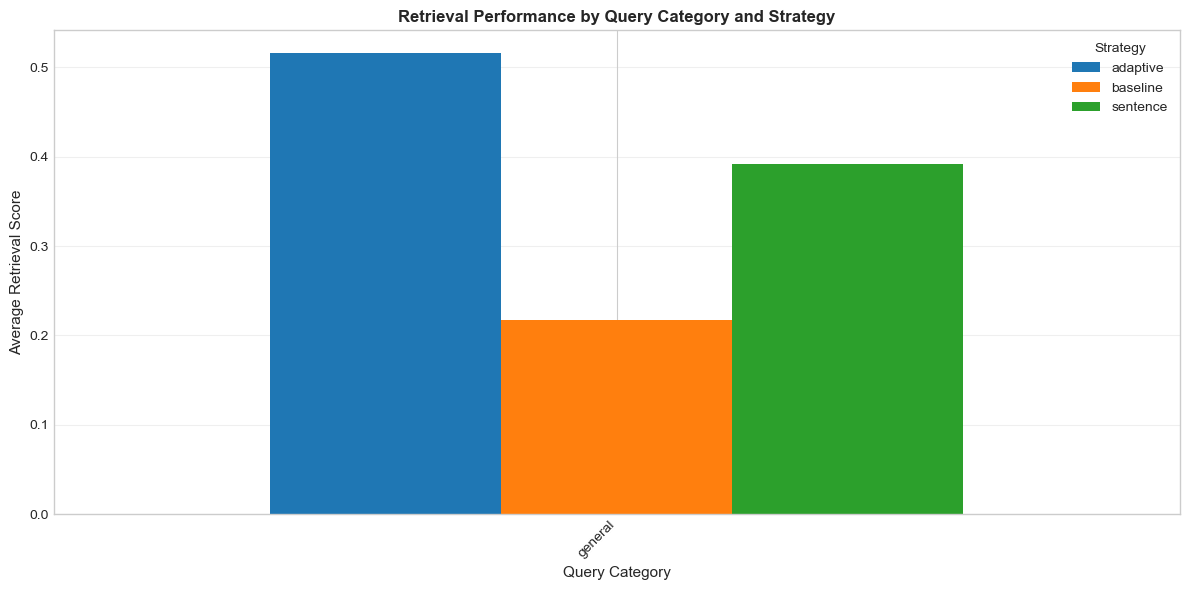

✅ Saved plot to results\category_analysis.png


In [13]:
# Category analysis
category_strategy = df.groupby(["category", "strategy"])["avg_score"].mean().reset_index()
pivot = category_strategy.pivot(index="category", columns="strategy", values="avg_score")

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c"], width=0.8)
ax.set_ylabel("Average Retrieval Score", fontsize=11)
ax.set_xlabel("Query Category", fontsize=11)
ax.set_title("Retrieval Performance by Query Category and Strategy", 
             fontsize=12, fontweight="bold")
ax.legend(title="Strategy", title_fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "category_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Saved plot to {RESULTS_DIR / 'category_analysis.png'}")

## 7. Summary and Conclusions

In [14]:
# Find best strategy
best_strategy = strategy_stats.loc[strategy_stats["avg_score_mean"].idxmax(), "strategy"]
best_avg_score = strategy_stats["avg_score_mean"].max()
overall_namespace_acc = df["namespace_correct"].mean()

print("=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)
print(f"\n✅ Best Performing Strategy (by retrieval score): {best_strategy}")
print(f"   Average Retrieval Score: {best_avg_score:.4f}")
print(f"\n✅ Overall Namespace Detection Accuracy: {overall_namespace_acc:.2%}")

# Category-specific recommendations
print(f"\n📊 Performance by Category:")
category_best = df.groupby(["category", "strategy"])["avg_score"].mean().reset_index()
category_best = category_best.loc[category_best.groupby("category")["avg_score"].idxmax()]
for _, row in category_best.iterrows():
    print(f"  {row['category']}: {row['strategy']} (score: {row['avg_score']:.4f})")

print(f"\n✅ All visualizations saved to: {RESULTS_DIR}")
print("=" * 70)

EVALUATION SUMMARY

✅ Best Performing Strategy (by retrieval score): adaptive
   Average Retrieval Score: 0.5259

✅ Overall Namespace Detection Accuracy: 98.33%

📊 Performance by Category:
  general: adaptive (score: 0.5156)

✅ All visualizations saved to: results


## 8. Additional Analysis (Optional)

In [15]:
# Additional analysis: Query-level performance
print("📊 Top performing queries by strategy:")
for strategy in df["strategy"].unique():
    strategy_df = df[df["strategy"] == strategy]
    top_queries = strategy_df.nlargest(3, "avg_score")[["query", "avg_score"]]
    print(f"\n{strategy.upper()}:")
    for _, row in top_queries.iterrows():
        print(f"  {row['query'][:50]}... (score: {row['avg_score']:.4f})")

# Additional analysis: Worst performing queries
print("\n\n📊 Queries with lowest scores:")
worst_queries = df.nsmallest(5, "avg_score")[["query", "strategy", "avg_score"]]
for _, row in worst_queries.iterrows():
    print(f"  {row['strategy']}: {row['query'][:50]}... (score: {row['avg_score']:.4f})")

📊 Top performing queries by strategy:

ADAPTIVE:
  מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?... (score: 0.7107)
  מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?... (score: 0.7107)
  איך פונים לשירותים כלליים שאינם תשלומים — למשל תלו... (score: 0.6881)

BASELINE:
  מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?... (score: 0.5081)
  מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?... (score: 0.4524)
  מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?... (score: 0.4524)

SENTENCE:
  מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?... (score: 0.6338)
  מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?... (score: 0.6000)
  מהו מספר הטלפון של המוקד העירוני של עיריית חיפה?... (score: 0.6000)


📊 Queries with lowest scores:
  baseline: אם אני רוצה להחליף מחזיק בנכס (למשל דירה שכורה) — ... (score: 0.0232)
  baseline: אם אני רוצה להחליף מחזיק בנכס (למשל דירה שכורה) — ... (score: 0.0232)
  baseline: איך מזמינים שירותי חינוך בלתי פורמלי כמו חוגים או ... (score: 0.0472)
  baseline: איך מזמ

## 9. Answer Quality Analysis (if available)

## 10. Comparison Across K Values

Compare performance for each strategy across different k values (k3, k5, k10).


📊 Performance by Strategy and K Value:
   strategy config  avg_score_mean  avg_score_std  namespace_correct_mean  \
0  adaptive    k10          0.5030         0.1347                     1.0   
1  adaptive     k3          0.5259         0.1247                     1.0   
2  adaptive     k5          0.5166         0.1284                     1.0   

   num_results_mean  
0              10.0  
1               3.0  
2               5.0  


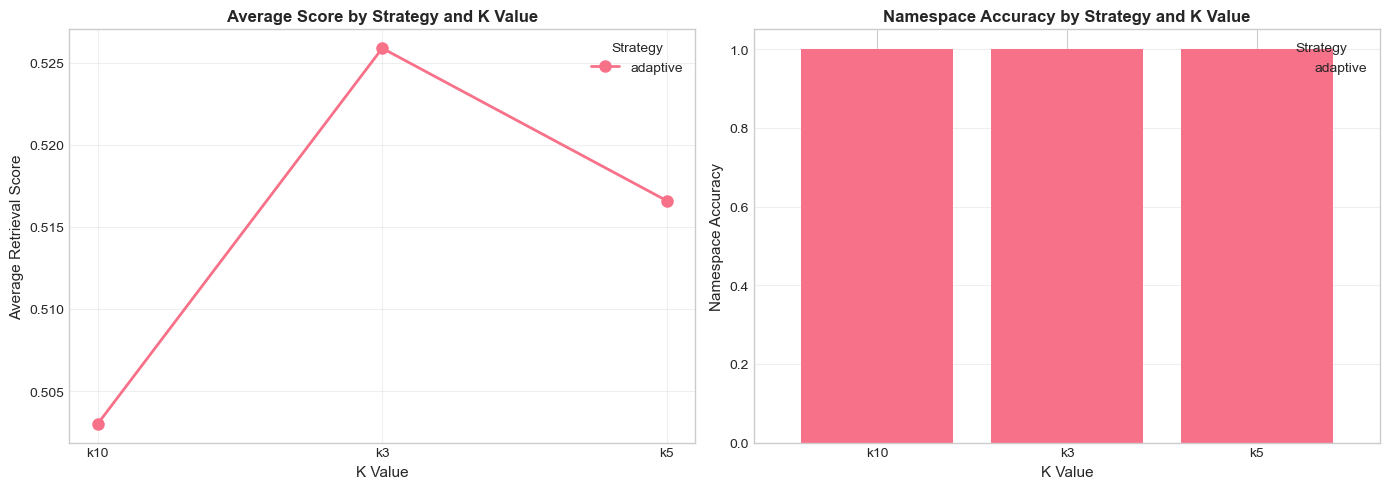


📈 Key Findings:
  adaptive: Best K = k3 (score: 0.5259)


In [16]:
# Filter to k value configurations
k_configs = ['k3', 'k5', 'k10']
k_df = df[df['config'].isin(k_configs)].copy()

if len(k_df) > 0:
    # Group by strategy and k value
    k_comparison = k_df.groupby(['strategy', 'config']).agg({
        'avg_score': ['mean', 'std'],
        'namespace_correct': 'mean',
        'num_results': 'mean'
    }).round(4)
    k_comparison.columns = ['_'.join(col).strip() if col[1] else col[0] for col in k_comparison.columns]
    k_comparison = k_comparison.reset_index()
    
    print("📊 Performance by Strategy and K Value:")
    print(k_comparison)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Average score by k value
    ax = axes[0]
    for strategy in k_df['strategy'].unique():
        strategy_data = k_comparison[k_comparison['strategy'] == strategy]
        ax.plot(strategy_data['config'], strategy_data['avg_score_mean'], 
               marker='o', label=strategy, linewidth=2, markersize=8)
    ax.set_xlabel('K Value', fontsize=11)
    ax.set_ylabel('Average Retrieval Score', fontsize=11)
    ax.set_title('Average Score by Strategy and K Value', fontsize=12, fontweight='bold')
    ax.legend(title='Strategy')
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
    
    # Namespace accuracy by k value
    ax = axes[1]
    namespace_acc_k = k_df.groupby(['strategy', 'config'])['namespace_correct'].mean().reset_index()
    pivot_acc = namespace_acc_k.pivot(index='config', columns='strategy', values='namespace_correct')
    pivot_acc.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('K Value', fontsize=11)
    ax.set_ylabel('Namespace Accuracy', fontsize=11)
    ax.set_title('Namespace Accuracy by Strategy and K Value', fontsize=12, fontweight='bold')
    ax.legend(title='Strategy')
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📈 Key Findings:")
    for strategy in k_df['strategy'].unique():
        strategy_data = k_comparison[k_comparison['strategy'] == strategy]
        if len(strategy_data) > 0:
            best_k = strategy_data.loc[strategy_data['avg_score_mean'].idxmax(), 'config']
            best_score = strategy_data['avg_score_mean'].max()
            print(f"  {strategy}: Best K = {best_k} (score: {best_score:.4f})")
else:
    print("⚠️  No k value configurations found. Ensure results_k3, results_k5, results_k10 exist.")


## 11. Comparison Across Chunk Sizes

Compare performance for each strategy across different chunk sizes (small, medium).


📊 Performance by Strategy and Chunk Size:
   strategy         config  avg_score_mean  avg_score_std  \
0  adaptive  medium_chunks          0.5156         0.1307   
1  adaptive   small_chunks          0.5166         0.1284   
2  baseline  medium_chunks          0.1865         0.1131   
3  baseline   small_chunks          0.2796         0.1324   
4  sentence  medium_chunks          0.3792         0.1155   
5  sentence   small_chunks          0.4177         0.1207   

   namespace_correct_mean  num_results_mean  unique_docs_mean  
0                     1.0               5.0              3.65  
1                     1.0               5.0              3.50  
2                     0.9               3.7              3.60  
3                     1.0               4.9              4.25  
4                     1.0               5.0              4.40  
5                     1.0               5.0              3.90  


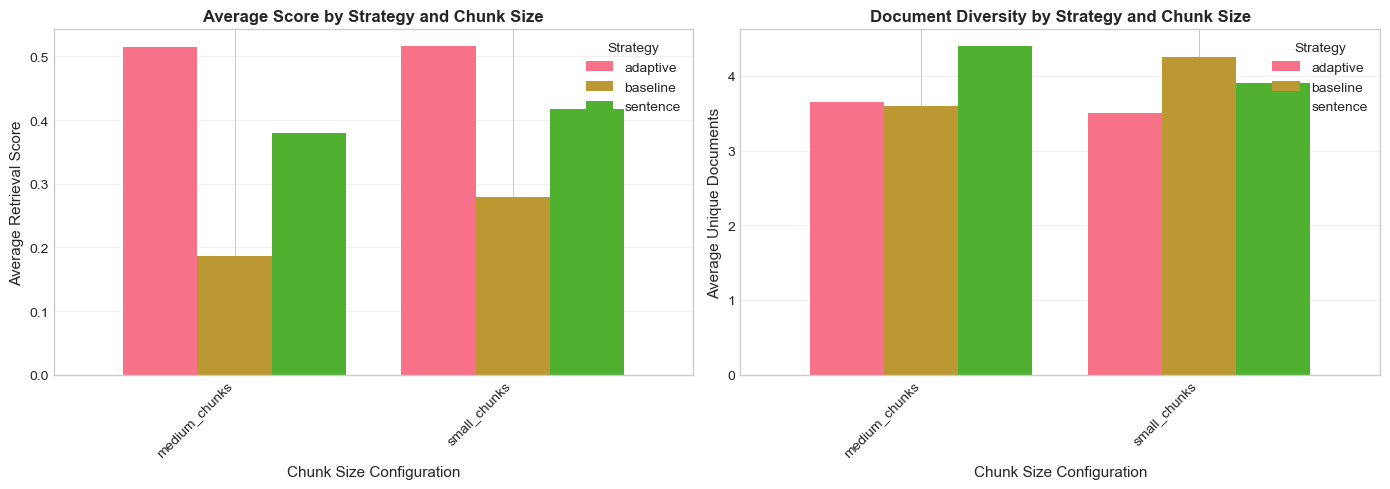


📈 Key Findings:
  baseline: Best chunk size = small_chunks (score: 0.2796)
  sentence: Best chunk size = small_chunks (score: 0.4177)
  adaptive: Best chunk size = small_chunks (score: 0.5166)


In [17]:
# Filter to chunk size configurations
chunk_configs = ['small_chunks', 'medium_chunks']
chunk_df = df[df['config'].isin(chunk_configs)].copy()

if len(chunk_df) > 0:
    # Group by strategy and chunk size
    chunk_comparison = chunk_df.groupby(['strategy', 'config']).agg({
        'avg_score': ['mean', 'std'],
        'namespace_correct': 'mean',
        'num_results': 'mean',
        'unique_docs': 'mean'
    }).round(4)
    chunk_comparison.columns = ['_'.join(col).strip() if col[1] else col[0] for col in chunk_comparison.columns]
    chunk_comparison = chunk_comparison.reset_index()
    
    print("📊 Performance by Strategy and Chunk Size:")
    print(chunk_comparison)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Average score by chunk size
    ax = axes[0]
    chunk_means = chunk_df.groupby(['strategy', 'config'])['avg_score'].mean().reset_index()
    pivot_score = chunk_means.pivot(index='config', columns='strategy', values='avg_score')
    pivot_score.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Chunk Size Configuration', fontsize=11)
    ax.set_ylabel('Average Retrieval Score', fontsize=11)
    ax.set_title('Average Score by Strategy and Chunk Size', fontsize=12, fontweight='bold')
    ax.legend(title='Strategy')
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Unique docs by chunk size
    ax = axes[1]
    unique_docs_means = chunk_df.groupby(['strategy', 'config'])['unique_docs'].mean().reset_index()
    pivot_docs = unique_docs_means.pivot(index='config', columns='strategy', values='unique_docs')
    pivot_docs.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Chunk Size Configuration', fontsize=11)
    ax.set_ylabel('Average Unique Documents', fontsize=11)
    ax.set_title('Document Diversity by Strategy and Chunk Size', fontsize=12, fontweight='bold')
    ax.legend(title='Strategy')
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📈 Key Findings:")
    for strategy in chunk_df['strategy'].unique():
        strategy_data = chunk_comparison[chunk_comparison['strategy'] == strategy]
        if len(strategy_data) > 0:
            best_chunk = strategy_data.loc[strategy_data['avg_score_mean'].idxmax(), 'config']
            best_score = strategy_data['avg_score_mean'].max()
            print(f"  {strategy}: Best chunk size = {best_chunk} (score: {best_score:.4f})")
else:
    print("⚠️  No chunk size configurations found. Ensure small_chunks and medium_chunks exist.")


## 12. Comparison Across Overlap Sizes

Compare performance for each strategy across different overlap sizes (small_overlap, medium_chunks).


📊 Performance by Strategy and Overlap Size:
   strategy         config  avg_score_mean  avg_score_std  \
0  adaptive  medium_chunks          0.5156         0.1307   
1  adaptive  small_overlap          0.5156         0.1307   
2  baseline  medium_chunks          0.1865         0.1131   
3  baseline  small_overlap          0.1865         0.1131   
4  sentence  medium_chunks          0.3792         0.1155   
5  sentence  small_overlap          0.3792         0.1155   

   namespace_correct_mean  num_results_mean  
0                     1.0               5.0  
1                     1.0               5.0  
2                     0.9               3.7  
3                     0.9               3.7  
4                     1.0               5.0  
5                     1.0               5.0  


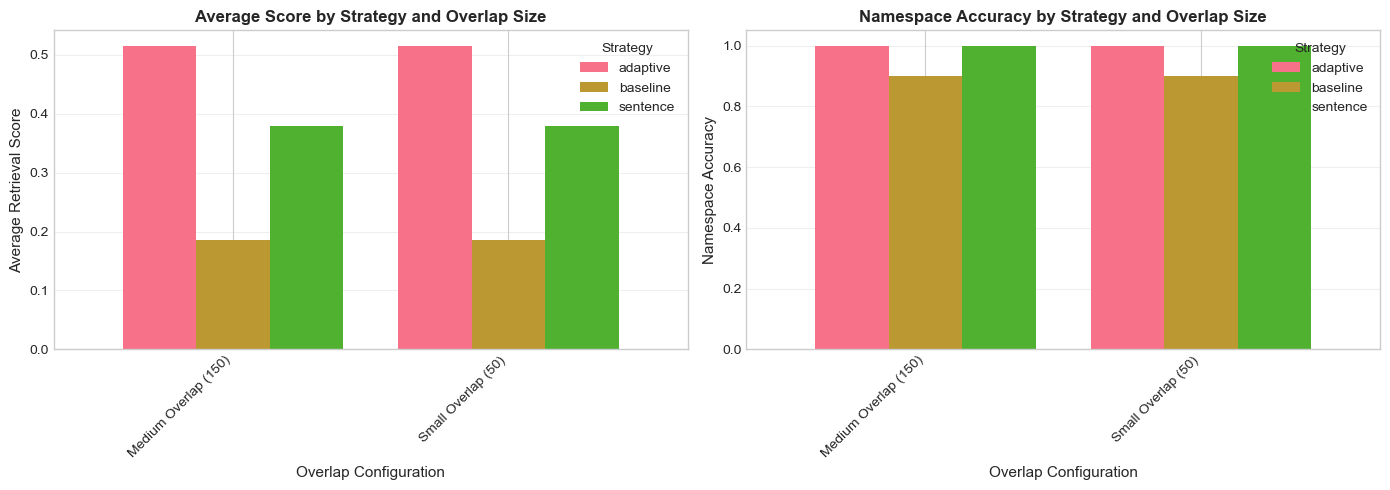


📈 Key Findings:
  baseline: Best overlap = medium_chunks (score: 0.1865)
  sentence: Best overlap = medium_chunks (score: 0.3792)
  adaptive: Best overlap = medium_chunks (score: 0.5156)


In [18]:
# Filter to overlap configurations (medium_chunks has overlap 150, small_overlap has overlap 50)
overlap_configs = ['small_overlap', 'medium_chunks']
overlap_df = df[df['config'].isin(overlap_configs)].copy()

if len(overlap_df) > 0:
    # Map config names to overlap sizes for clarity
    overlap_df['overlap_label'] = overlap_df['config'].map({
        'small_overlap': 'Small Overlap (50)',
        'medium_chunks': 'Medium Overlap (150)'
    })
    
    # Group by strategy and overlap
    overlap_comparison = overlap_df.groupby(['strategy', 'config']).agg({
        'avg_score': ['mean', 'std'],
        'namespace_correct': 'mean',
        'num_results': 'mean'
    }).round(4)
    overlap_comparison.columns = ['_'.join(col).strip() if col[1] else col[0] for col in overlap_comparison.columns]
    overlap_comparison = overlap_comparison.reset_index()
    
    print("📊 Performance by Strategy and Overlap Size:")
    print(overlap_comparison)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Average score by overlap
    ax = axes[0]
    overlap_means = overlap_df.groupby(['strategy', 'overlap_label'])['avg_score'].mean().reset_index()
    pivot_score = overlap_means.pivot(index='overlap_label', columns='strategy', values='avg_score')
    pivot_score.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Overlap Configuration', fontsize=11)
    ax.set_ylabel('Average Retrieval Score', fontsize=11)
    ax.set_title('Average Score by Strategy and Overlap Size', fontsize=12, fontweight='bold')
    ax.legend(title='Strategy')
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Namespace accuracy by overlap
    ax = axes[1]
    namespace_acc_overlap = overlap_df.groupby(['strategy', 'overlap_label'])['namespace_correct'].mean().reset_index()
    pivot_acc = namespace_acc_overlap.pivot(index='overlap_label', columns='strategy', values='namespace_correct')
    pivot_acc.plot(kind='bar', ax=ax, width=0.8)
    ax.set_xlabel('Overlap Configuration', fontsize=11)
    ax.set_ylabel('Namespace Accuracy', fontsize=11)
    ax.set_title('Namespace Accuracy by Strategy and Overlap Size', fontsize=12, fontweight='bold')
    ax.legend(title='Strategy')
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📈 Key Findings:")
    for strategy in overlap_df['strategy'].unique():
        strategy_data = overlap_comparison[overlap_comparison['strategy'] == strategy]
        if len(strategy_data) > 0:
            best_overlap = strategy_data.loc[strategy_data['avg_score_mean'].idxmax(), 'config']
            best_score = strategy_data['avg_score_mean'].max()
            print(f"  {strategy}: Best overlap = {best_overlap} (score: {best_score:.4f})")
else:
    print("⚠️  No overlap configurations found. Ensure small_overlap and medium_chunks exist.")


In [19]:
# Analyze answer quality if answers were generated
if ENABLE_ANSWER_ANALYSIS and "llm_score" in df.columns and "answer" in df.columns:
    print("📊 Answer Quality Analysis:")
    print("=" * 70)
    
    # LLM score by strategy
    llm_by_strategy = df.groupby("strategy")["llm_score"].agg(["mean", "std", "count"]).round(4)
    print("\nLLM Answer Quality Score by Strategy:")
    print(llm_by_strategy)
    
    # Precision/Recall if available
    if "precision_at_k" in df.columns and "recall_at_k" in df.columns:
        pr_by_strategy = df.groupby("strategy")[["precision_at_k", "recall_at_k"]].mean().round(4)
        print("\nPrecision and Recall by Strategy:")
        print(pr_by_strategy)
        
        # Plot precision/recall
        fig, ax = plt.subplots(figsize=(10, 6))
        pr_by_strategy.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e"])
        ax.set_ylabel("Score", fontsize=11)
        ax.set_xlabel("Chunking Strategy", fontsize=11)
        ax.set_title("Precision and Recall by Strategy", fontsize=12, fontweight="bold")
        ax.legend(title="Metric")
        ax.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / "precision_recall_by_strategy.png", dpi=300, bbox_inches="tight")
        plt.show()
        print(f"✅ Saved plot to {RESULTS_DIR / 'precision_recall_by_strategy.png'}")
    
    # Plot LLM scores
    fig, ax = plt.subplots(figsize=(10, 6))
    llm_means = df.groupby("strategy")["llm_score"].mean().sort_values(ascending=False)
    bars = ax.bar(llm_means.index, llm_means.values, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
    ax.set_ylabel("Average LLM Quality Score", fontsize=11)
    ax.set_xlabel("Chunking Strategy", fontsize=11)
    ax.set_title("Answer Quality by Strategy (LLM Grading)", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    for i, (strategy, val) in enumerate(llm_means.items()):
        ax.text(i, val + 0.02, f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "llm_score_by_strategy.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved plot to {RESULTS_DIR / 'llm_score_by_strategy.png'}")
    
else:
    print("ℹ️ Answer evaluation data not available in results.")
    print("   To enable answer evaluation, modify the evaluation script to generate answers.")

ℹ️ Answer evaluation data not available in results.
   To enable answer evaluation, modify the evaluation script to generate answers.
